In [11]:
!pip install matplotlib scikit-learn tables


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 2.8 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 6.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [tables]2m5/6 [tables]]


In [6]:

import tensorflow as tf
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### 1. Load the TCIR Dataset

In [12]:
data_path = 'TCIR-ALL_2017.h5'

# Load labels
print('Loading labels...')
data_info = pd.read_hdf(data_path, key='info', mode='r')
labels = data_info['Vmax'].values # Vmax is the intensity in knots

# Load images
print('Loading images (this may take a moment depending on RAM)...')
with h5py.File(data_path, 'r') as hf:
    # matrix is N x 201 x 201 x 4
    data_matrix = hf['matrix'][:]

print(f'Images shape: {data_matrix.shape}')
print(f'Labels shape: {labels.shape}')

Loading labels...
Loading images (this may take a moment depending on RAM)...
Images shape: (4580, 201, 201, 4)
Labels shape: (4580,)


### 2. Preprocess Data

In [13]:
# The IR1 channel is the first channel (index 0)
# Let's extract only IR1 to follow the Hackathon prompt's focus on Infrared
X_ir = data_matrix[:, :, :, 0] # Shape: (N, 201, 201)

# Handle NaNs (Replace with 0 or a large negative number since it's temperature)
X_ir = np.nan_to_num(X_ir, nan=0.0)

# Expand dims to make it (N, 201, 201, 1) as required by TF CNNs
X_ir = np.expand_dims(X_ir, axis=-1)

# Handle NaNs in labels as well
valid_indices = ~np.isnan(labels)
X_ir = X_ir[valid_indices]
labels = labels[valid_indices]

# Normalize images to [0, 1] range (assuming IR temps are typically between -100 and 50)
# A simple min-max scaling
min_val = np.min(X_ir)
max_val = np.max(X_ir)
X_ir_norm = (X_ir - min_val) / (max_val - min_val + 1e-8)

print(f'Cleaned Images shape: {X_ir_norm.shape}')
print(f'Cleaned Labels shape: {labels.shape}')

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X_ir_norm, labels, test_size=0.2, random_state=42)

print(f'Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}')

Cleaned Images shape: (4580, 201, 201, 1)
Cleaned Labels shape: (4580,)
Train size: 3664, Validation size: 916


### 3. Build Convolutional Neural Network

In [14]:
def build_cyclone_model(input_shape=(201, 201, 1)):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Convolutional Blocks
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    # Flatten and Dense layers
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    
    # OUTPUT LAYER: Regression (1 node, linear activation)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

model = build_cyclone_model()
model.summary()

I0000 00:00:1777352791.581492    1199 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 201, 201, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 201, 201, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,240,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,341,121 (39.45 MB)

 Trainable params: 10,341,121 (39.45 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

In [15]:
# Compile the model
# Using Mean Squared Error (MSE) for regression, and tracking Mean Absolute Error (MAE)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='mse', 
              metrics=['mae'])

# Define callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_cyclone_model.keras', 
                                                monitor='val_mae', 
                                                save_best_only=True, 
                                                mode='min')
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)

# Train!
# (We use a small batch size due to the large image dimensions)
history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val),
                    batch_size=16, 
                    epochs=20, 
                    callbacks=[checkpoint, early_stopping])

2026-04-28 05:06:50.082080: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 592117056 exceeds 10% of free system memory.
2026-04-28 05:06:54.478139: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 592117056 exceeds 10% of free system memory.


Epoch 1/20


2026-04-28 05:06:57.019507: I external/local_xla/xla/service/service.cc:163] XLA service 0x707c7000e520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-28 05:06:57.019549: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-04-28 05:06:57.136143: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-28 05:06:57.574108: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  7/229 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 2625.8948 - mae: 41.4845

I0000 00:00:1777352826.883518    1493 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


228/229 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 946.0121 - mae: 22.8367

2026-04-28 05:07:13.571075: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 148029264 exceeds 10% of free system memory.
2026-04-28 05:07:14.894689: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 148029264 exceeds 10% of free system memory.
2026-04-28 05:07:17.898650: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 40960000 exceeds 10% of free system memory.


229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - loss: 798.2628 - mae: 21.2882 - val_loss: 776.8959 - val_mae: 19.9868
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 735.5948 - mae: 20.8177 - val_loss: 719.4709 - val_mae: 20.5421
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 661.3641 - mae: 19.7215 - val_loss: 732.5432 - val_mae: 17.9122
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 482.7412 - mae: 16.5987 - val_loss: 451.9175 - val_mae: 15.3582
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 472.1218 - mae: 16.2846 - val_loss: 496.7646 - val_mae: 15.7689
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 462.8832 - mae: 16.1830 - val_loss: 409.0897 - val_mae: 15.1270
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 427.4294 - mae: 15.6230 - val_loss: 604.2761 - val_mae: 18.0042
Epoch 8/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 406.8398 - mae: 15.2226 - val_loss: 573.5556 - val_mae: 17.1066
Epoch 9

### 5. Evaluate

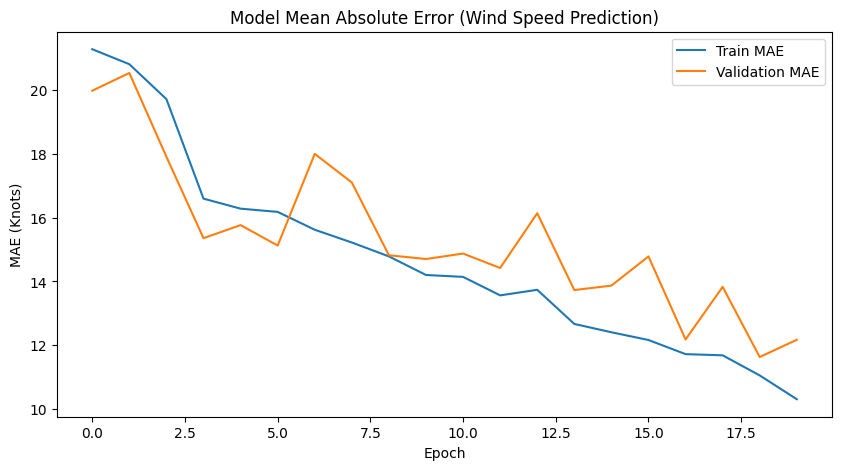

In [16]:
# Plot training & validation MAE values
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error (Wind Speed Prediction)')
plt.ylabel('MAE (Knots)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()